In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import os
import itertools
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
import logging
from matplotlib.patches import Rectangle, Circle, Ellipse
from astropy.convolution import interpolate_replace_nans, Gaussian2DKernel
from fancy_colorbar import plot_colorbar
import matplotlib.patheffects as path_effects
import matplotlib.transforms as transforms

from copy import deepcopy
from glob import glob

In [2]:
spice_raster = read_spice_l2_fits("../src/solo_L2_spice-n-ras_20221024T231535_V22_150995398-000.fits")

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-06 13:50:34 - astropy - WARNING: FITSFixedWarning: CROTA = 4.69616384906 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'. [astropy.wcs.wcs]
2025-03-06 13:50:34 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.969164 from DATEREF.
Set MJD-OBS to 59876.969164 from DATE-OBS.
Set MJD-BEG to 59876.969164 from DATE-BEG.
Set MJD-AVG to 59877.036108 from DATE-AVG.
Set MJD-END to 59877.103050 from DATE-END'.


In [3]:
spice_NeVIII_770_window = spice_raster["Ne VIII 770 - Peak"]

In [4]:
spice_NeVIII_data = spice_NeVIII_770_window.data[0].copy()
spice_NeVIII_data[spice_NeVIII_data < -0] = np.nan
spice_window_mask = np.isfinite(spice_NeVIII_data[:,120:700,:]).any(axis=(1,2))
spice_NeVIII_wvl = spice_NeVIII_770_window.spectral_axis.to_value(u.AA)[spice_window_mask]

start_wvl_index, end_wvl_index = np.where(spice_window_mask == True)[0][np.r_[0,-1]]

spice_NeVIII_header = spice_NeVIII_770_window.meta.original_header.copy()
spice_NeVIII_header_new_naxis3 = np.sum(spice_window_mask)
spice_NeVIII_header_new_crpix3 = (1 + spice_NeVIII_header_new_naxis3)/2.
spice_NeVIII_header_new_crval3 = ((start_wvl_index + end_wvl_index)/2. + 1 - spice_NeVIII_header['CRPIX3'])*spice_NeVIII_header['CDELT3'] + \
                                 spice_NeVIII_header['CRVAL3']

spice_NeVIII_header["NAXIS3"] = spice_NeVIII_header_new_naxis3
spice_NeVIII_header["CRPIX3"] = spice_NeVIII_header_new_crpix3
spice_NeVIII_header["CRVAL3"] = spice_NeVIII_header_new_crval3


spice_NeVIII_data_bg = deepcopy(spice_NeVIII_data)
spice_NeVIII_data_bg[spice_NeVIII_data_bg > np.nanpercentile(spice_NeVIII_data, 15, axis=0)[np.newaxis,:,:]] = np.nan
spice_NeVIII_data_bg = np.nanmedian(spice_NeVIII_data_bg, axis=0)

spice_NeVIII_data_bg_rm = spice_NeVIII_data - spice_NeVIII_data_bg[np.newaxis,:,:] #np.nanmin(spice_NeVIII_data, axis=0)[np.newaxis,:,:]
spice_NeVIII_data_bg_rm = spice_NeVIII_data_bg_rm[spice_window_mask,120:700,:]

# kernel = Gaussian2DKernel(3)
# for ii in range(spice_NeVIII_data_bg_rm.shape[2]):
#     spice_NeVIII_data_bg_rm[:, :, ii] = interpolate_replace_nans(spice_NeVIII_data_bg_rm[:, :, ii], kernel)

rebin_facs = [1,2,1]
plot_aspect = spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1']*rebin_facs[1]/rebin_facs[2]

spice_NeVIII_data_bin = bindown(spice_NeVIII_data_bg_rm,np.round(np.array(spice_NeVIII_data_bg_rm.shape)/rebin_facs).astype(np.int32))
spice_NeVIII_window_start = np.argmax(np.isfinite(spice_NeVIII_data_bin), axis=0)
spice_NeVIII_window_end = spice_NeVIII_data_bin.shape[0] - 1 - np.argmax(np.isfinite(spice_NeVIII_data_bin[::-1,:,:]), axis=0)

spice_NeVIII_data_bin[19:21,200:202,:] = np.nan # mask some hot pixels

# spice_NeVIII_window_start = np.zeros(spice_NeVIII_data_bin.shape[1:]).astype(np.int32)
# spice_NeVIII_window_end = (np.ones(spice_NeVIII_data_bin.shape[1:])*(spice_NeVIII_data_bin.shape[0] - 1)).astype(np.int32)

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/scratch/tmp.25368268.zhuyin/ipykernel_774061/2556713602.py:21: RuntimeWarning: All-NaN slice encountered
  spice_NeVIII_data_bg = np.nanmedian(spice_NeVIII_data_bg, axis=0)


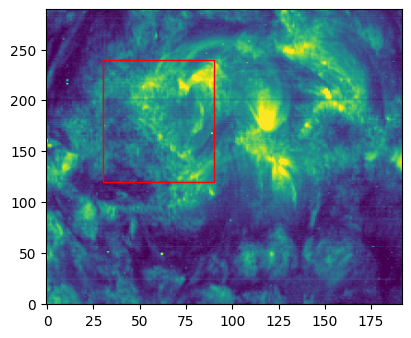

In [5]:
fig, ax = plt.subplots(figsize=(4,6), layout="constrained")
ax.imshow(np.nansum(spice_NeVIII_data_bin, axis=0), origin="lower", aspect=plot_aspect,
            norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(spice_NeVIII_data_bin, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(spice_NeVIII_data_bin, axis=0), 99.5),
            stretch=AsinhStretch()))

rect_box_1 = Rectangle((30, 120), 60, 120, linewidth=1, edgecolor='r', facecolor='none')

ax.add_patch(rect_box_1)

In [6]:
spice_NeVIII_data_bin_r1 = spice_NeVIII_data_bin[:,120:240,30:90]


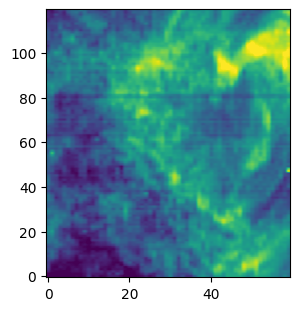

In [7]:
fig, ax = plt.subplots(figsize=(3,3), layout="constrained")

ax.imshow(np.nansum(spice_NeVIII_data_bin_r1, axis=0), origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r1, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(spice_NeVIII_data_bin_r1, axis=0), 99.5),
            stretch=AsinhStretch()), aspect=plot_aspect)

In [8]:
yl_core_xpo = 1.8

yl_wing_xpo = 1

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -25*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([2.5, 1.11])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([13.0, 4.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.28

In [9]:
spice_NeVIII_corr_data_r1, spice_NeVIII_cor_chi2s_r1, metadict_r1 = \
    correct_spice_raster(spice_NeVIII_data_bin_r1.transpose([2,1,0]), spice_NeVIII_header, fwhm_core0_yl, fwhm_wing0_yl, 
                        psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                        yl_wing_xpo=yl_wing_xpo,
                        super_fac=1, chi2_th = 0.5,
                        psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
                        
spice_NeVIII_corr_data_r1 = spice_NeVIII_corr_data_r1.transpose([2,1,0])

Correcting Ne VIII 770 - Peak; ref. wavelength=768.456459599
Computing PSF Core:
4.980204209210252 % done after 0.23832964897155762 seconds
9.98124609293603 % done after 0.4762439727783203 seconds
14.982287976661805 % done after 0.7136819362640381 seconds
19.98332986038758 % done after 0.9513566493988037 seconds
24.984371744113357 % done after 1.1886084079742432 seconds
29.985413627839133 % done after 1.4273850917816162 seconds
34.98645551156491 % done after 1.6644811630249023 seconds
39.98749739529069 % done after 1.901519775390625 seconds
44.988539279016464 % done after 2.139228582382202 seconds
49.98958116274224 % done after 2.3771753311157227 seconds
54.990623046468016 % done after 2.614896297454834 seconds
59.99166493019379 % done after 2.853239059448242 seconds
64.99270681391957 % done after 3.0911829471588135 seconds
69.99374869764534 % done after 3.329329252243042 seconds
74.99479058137112 % done after 3.5675737857818604 seconds
79.9958324650969 % done after 3.8037967681884766 

2025-03-06 13:51:07 - numba.core.transforms - INFO: finding looplift candidates
/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py:83: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_masked_medfilt_inner" failed type inference due to: Use of unsupported NumPy function 'numpy.unravel_index' or unsupported use of the function.

File "../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner(flatinds,data,footprint_inds,footprint_ind_offset,tparg,dat_pad_shape,data_fppad,mask_fppad,data_filt):
    <source elided>
    for ind in flatinds:
        ijkpad = np.unravel_index(ind,data.shape)+footprint_inds-footprint_ind_offset
        ^

During: typing of get attribute at /cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py (86)

File "../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner(flati

Correcting the PSF:
0.2373502254486084 s; Finished slit index 0 of 60 , chi^2= 0.41305386910886543
0.4774961471557617 s; Finished slit index 1 of 60 , chi^2= 0.40159536301563387
0.716839075088501 s; Finished slit index 2 of 60 , chi^2= 0.36961274907355024
0.9595227241516113 s; Finished slit index 3 of 60 , chi^2= 0.3457252122173405
1.198812484741211 s; Finished slit index 4 of 60 , chi^2= 0.36322239622760777
1.4337575435638428 s; Finished slit index 5 of 60 , chi^2= 0.41019360832276947
1.667656660079956 s; Finished slit index 6 of 60 , chi^2= 0.3240936625942773
1.9050683975219727 s; Finished slit index 7 of 60 , chi^2= 0.3725659650738695
2.139448881149292 s; Finished slit index 8 of 60 , chi^2= 0.3633311618919757
2.374561071395874 s; Finished slit index 9 of 60 , chi^2= 0.36270837391746313
2.6107430458068848 s; Finished slit index 10 of 60 , chi^2= 0.3134356534586505
2.85102915763855 s; Finished slit index 11 of 60 , chi^2= 0.3693895648608523
3.0854172706604004 s; Finished slit index 1

In [10]:
def func_NeVIII_770_sg(x, wvl_770, int_770, wid_770, b):
    return gaussian(x, wvl_770, int_770, wid_770) + \
           b

In [11]:
def work_fit_single_spec(args):
    (NeVIII_770_wvl, NeVIII_770_data_rebin,
    NeVIII_770_window_start, NeVIII_window_end,
    ii, jj) = args
    
    try:
        data_slice = NeVIII_770_data_rebin[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1,
                                           ii, jj]
        
        p0 = [
            NeVIII_770_wvl[np.nanargmax(data_slice)],  # wavelength of max
            np.nanmax(data_slice),  # intensity 
            0.8,  # width
            0   # background
        ]
        
        # Bounds for parameters
        bounds = (
            (0, 0, 0, -np.inf),
            (np.inf, np.inf, np.inf, np.inf)
        )
        
        # Perform curve fitting
        popt, pcov = curve_fit(
            func_NeVIII_770_sg,
            NeVIII_770_wvl[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1],
            data_slice,
            p0=p0,
            bounds=bounds,
            nan_policy="omit"
        )

        perr = np.sqrt(np.diag(pcov))

        if np.any(~np.isfinite(popt)) or np.any(~np.isfinite(perr)) \
            or np.any(np.abs(perr[:3]/popt[:3]) > 0.3):
            return (ii, jj, None)
        else:
            return (ii, jj, popt)
    
    except Exception as e:
        # Return None or a special marker for failed fits
        return (ii, jj, None)


In [12]:
def fit_parallel(NeVIII_770_wvl, NeVIII_770_data_rebin, NeVIII_770_window_start=spice_NeVIII_window_start,
                 NeVIII_770_window_end=spice_NeVIII_window_end, ncpu=8):
    # Prepare input arguments for each position
    input_args = [
        (NeVIII_770_wvl, NeVIII_770_data_rebin,
         NeVIII_770_window_start, NeVIII_770_window_end,
         ii, jj) 
        for ii in range(NeVIII_770_data_rebin.shape[1]) 
        for jj in range(NeVIII_770_data_rebin.shape[2])
    ]
    
    # Prepare result arrays
    shape = NeVIII_770_data_rebin.shape[1:]
    NeVIII_fit_wvl = np.ones(shape)*np.nan
    NeVIII_fit_int = np.ones(shape)*np.nan
    NeVIII_fit_wid = np.ones(shape)*np.nan
    NeVIII_fit_b = np.ones(shape)*np.nan
    
    # Use ProcessPoolExecutor to parallelize fitting
    with ProcessPoolExecutor(max_workers=ncpu) as executor:
        # Submit all tasks
        futures = [executor.submit(work_fit_single_spec, args) for args in input_args]
        
        # Process results as they complete
        for future in concurrent.futures.as_completed(futures):
            result = future.result()
            
            # Check if fitting was successful
            if result[2] is not None:
                ii, jj, popt = result
                
                # Store results in respective arrays
                NeVIII_fit_wvl[ii, jj] = popt[0]
                NeVIII_fit_int[ii, jj] = popt[1]
                NeVIII_fit_wid[ii, jj] = popt[2]
                NeVIII_fit_b[ii, jj] = popt[3]
    
    return (
        NeVIII_fit_wvl, 
        NeVIII_fit_int, 
        NeVIII_fit_wid, 
        NeVIII_fit_b
    )

In [13]:
(NeVIII_orig_fit_wvl_r1, NeVIII_orig_fit_int_r1, NeVIII_orig_fit_wid_r1,
NeVIII_orig_fit_b_r1) = fit_parallel(spice_NeVIII_wvl,spice_NeVIII_data_bin_r1)

In [14]:
(NeVIII_corr_fit_wvl_r1, NeVIII_corr_fit_int_r1, NeVIII_corr_fit_wid_r1,
NeVIII_corr_fit_b_r1) = fit_parallel(spice_NeVIII_wvl,spice_NeVIII_corr_data_r1)

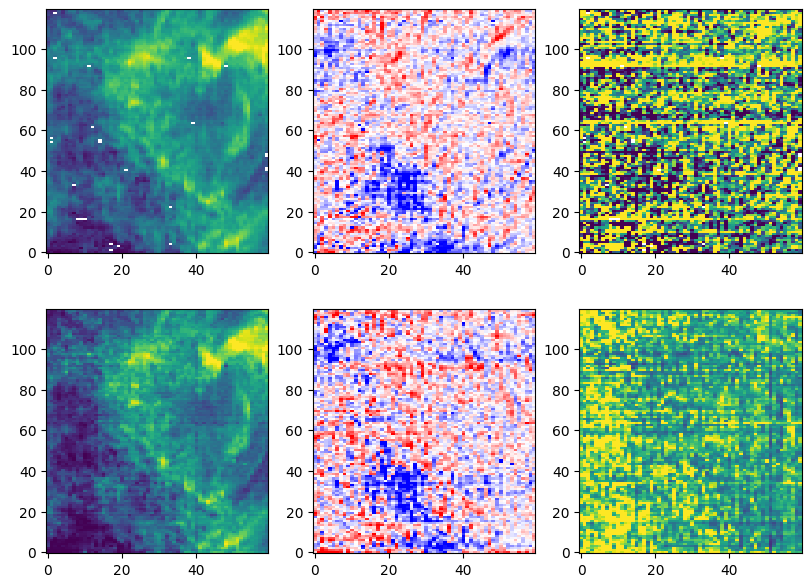

In [15]:
fig, ((ax1,ax2,ax3), (ax4,ax5,ax6)) = plt.subplots(2,3,figsize=(8,6), layout="constrained")

ax1.imshow(NeVIII_orig_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_orig_fit_int_r1, 0.1),
                                vmax=np.nanpercentile(NeVIII_orig_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax2.imshow((NeVIII_orig_fit_wvl_r1 - np.nanmedian(NeVIII_orig_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(NeVIII_orig_fit_wid_r1, norm=ImageNormalize(vmin=0.8, vmax=0.9),
            origin="lower", aspect=plot_aspect, interpolation='none')

ax4.imshow(NeVIII_corr_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_corr_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_corr_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax5.imshow((NeVIII_corr_fit_wvl_r1 - np.nanmedian(NeVIII_corr_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax6.imshow(NeVIII_corr_fit_wid_r1, norm=ImageNormalize(vmin=0.3, vmax=0.6),
            origin="lower", aspect=plot_aspect, interpolation='none')

In [16]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}'}

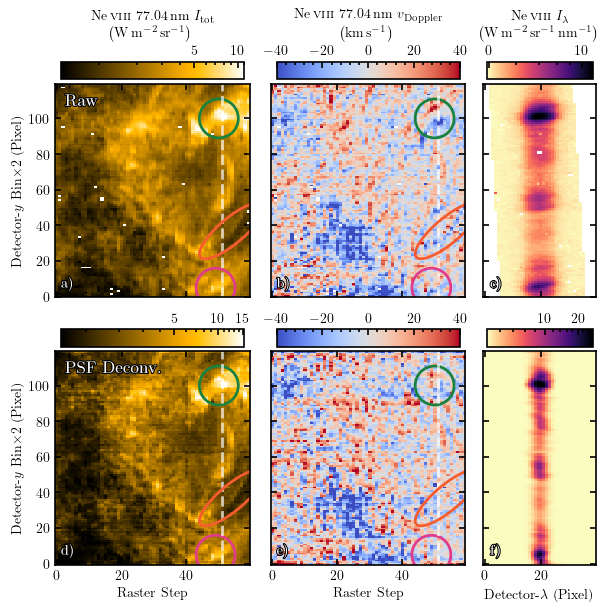

In [17]:
with plt.rc_context(ms_style_dict):

    example_x_index = 51

    fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=(6,6), layout="constrained",
                                              gridspec_kw={'width_ratios': [1,1,0.55]})
    
    im1 = ax1.imshow(NeVIII_orig_fit_int_r1, origin="lower",
    norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_orig_fit_int_r1, 0.1),
                                vmax=np.nanpercentile(NeVIII_orig_fit_int_r1, 99.9),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation="none",
                                cmap="sdoaia171")
    clb1, clb_ax1 = plot_colorbar(im1, ax1, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")

    clb_ax1.set_title(r"Ne\,\textsc{viii} 77.04\,nm $I_{\rm tot}$" + "\n" + \
                      r"$\mathrm{\left(W\,m^{-2}\,sr^{-1}\right)}$", fontsize=10)

    im2 = ax2.imshow((NeVIII_orig_fit_wvl_r1 - np.nanmedian(NeVIII_orig_fit_wvl_r1, axis=0)[np.newaxis,:])/770.428*const.c.to_value(u.km/u.s),
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="coolwarm", origin="lower",
            aspect=plot_aspect, interpolation="none")

    clb2, clb_ax2 = plot_colorbar(im2, ax2, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")
    
    clb_ax2.set_title(r"Ne\,\textsc{viii} 77.04\,nm $v_{\rm Doppler}$" + "\n" + \
                      r"$\mathrm{\left(km\,s^{-1}\right)}$", fontsize=10)

    im3 = ax3.imshow(spice_NeVIII_data_bin_r1[:, :, example_x_index].T, origin="lower", aspect="auto", 
           norm=ImageNormalize(vmin=np.nanpercentile(spice_NeVIII_data_bin_r1[:, :, example_x_index],0.5),
                               vmax=np.nanpercentile(spice_NeVIII_data_bin_r1[:, :, example_x_index],99.9),
                               stretch=AsinhStretch(0.3)), interpolation="none", cmap="magma_r")

    clb3, clb_ax3 = plot_colorbar(im3, ax3, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")

    clb_ax3.set_title(r"Ne\,\textsc{viii} $I_{\lambda}$" + "\n" + \
                      r"$\mathrm{\left(W\,m^{-2}\,sr^{-1}\,nm^{-1}\right)}$", fontsize=10)
    
    im4 = ax4.imshow(NeVIII_corr_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_corr_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_corr_fit_int_r1, 99.9),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation="none",
                                cmap="sdoaia171")

    clb4, clb_ax4 = plot_colorbar(im4, ax4, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")

    im5 = ax5.imshow((NeVIII_corr_fit_wvl_r1 - np.nanmedian(NeVIII_corr_fit_wvl_r1, axis=0)[np.newaxis,:])/770.428*const.c.to_value(u.km/u.s),
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="coolwarm", origin="lower",
            aspect=plot_aspect, interpolation="none")

    clb5, clb_ax5 = plot_colorbar(im5, ax5, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")

    im6 = ax6.imshow(spice_NeVIII_corr_data_r1[:, :, example_x_index].T, origin="lower", aspect="auto", 
           norm=ImageNormalize(vmin=np.nanpercentile(spice_NeVIII_corr_data_r1[:, :, example_x_index],0.1),
                               vmax=np.nanpercentile(spice_NeVIII_corr_data_r1[:, :, example_x_index],99.9),
                               stretch=AsinhStretch(0.3)), interpolation="none", cmap="magma_r")

    clb6, clb_ax6 = plot_colorbar(im6, ax6, bbox_to_anchor=(0.03, 1.02, 0.94, 0.08),
                  fontsize=10, orientation="horizontal")

    ax1.tick_params(labelbottom=False, top=True, right=True)
    ax2.tick_params(labelleft=False, labelbottom=False, top=True, right=True)   
    ax3.tick_params(labelleft=False, labelbottom=False, top=True, right=True)
    ax4.tick_params(top=True, right=True)
    ax5.tick_params(labelleft=False, top=True, right=True)
    ax6.tick_params(labelleft=False, top=True, right=True)

    ax1.set_ylabel(r"Detector-$y$ Bin$\times$2  (Pixel)")
    ax4.set_ylabel(r"Detector-$y$ Bin$\times$2 (Pixel)")
    ax4.set_xlabel(r"Raster Step")
    ax5.set_xlabel(r"Raster Step")
    ax6.set_xlabel(r"Detector-$\lambda$ (Pixel)")

    for clb_ax_ in (clb_ax1, clb_ax2, clb_ax3, clb_ax4, clb_ax5, clb_ax6):
        clb_ax_.tick_params(top=True, labeltop=True, labelbottom=False, bottom=False, which="both")

    for ax_ in (ax1,ax2,ax4,ax5):
        ax_.axvline(example_x_index, color="w", lw=2, ls="--", alpha=0.7)

    for ax_, text_ in zip((ax1,ax2,ax4,ax5),
                          ("a", "b", "d", "e")):
        ax_.text(0.03,0.03,r"\textbf{{{:})}}".format(text_), transform=ax_.transAxes,
                va="bottom", ha="left", color="w", fontsize=10,
                path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])

    for ax_, text_ in zip((ax3,ax6),("c","f")):
        ax_.text(0.06,0.03,r"\textbf{{{:})}}".format(text_), transform=ax_.transAxes,
                va="bottom", ha="left", color="w", fontsize=10,
                path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])       

    ax1.text(0.05,0.95,r"\textbf{Raw}", transform=ax1.transAxes,
                va="top", ha="left", color="w", fontsize=12,
                path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])
    ax4.text(0.05,0.95,r"\textbf{PSF Deconv.}", transform=ax4.transAxes,
                va="top", ha="left", color="w", fontsize=12,
                path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'),path_effects.Normal()])
    
    target_r1_param = {'xy':(50, 100), 'width': 12, 'height': 12/plot_aspect, 'angle':0,
                       'ec':"#1B813E", 'fill': False, 'lw':2}
    
    target_r2_param = {'xy':(54, 37), 'width': 18, 'height': 5/plot_aspect, 'angle':60,
                       'ec':"#F75C2F", 'fill': False, 'lw':2}

    # the patches.Ellipse cannot handle the rotation 
    # in axes with different scales so we need to 
    # plot it explicitly 

    r2_t_ = np.linspace(0, 2*np.pi, 360)
    r2_x_ = target_r2_param['xy'][0] + \
            target_r2_param['width']*np.cos(r2_t_)*np.cos(np.deg2rad(target_r2_param['angle'])) - \
            target_r2_param['height']*plot_aspect*np.sin(r2_t_)*np.sin(np.deg2rad(target_r2_param['angle']))
    r2_y_ = target_r2_param['xy'][1] + \
            target_r2_param['width']*np.cos(r2_t_)*np.sin(np.deg2rad(target_r2_param['angle'])) + \
            target_r2_param['height']*plot_aspect*np.sin(r2_t_)*np.cos(np.deg2rad(target_r2_param['angle']))

    target_r3_param = {'xy':(49, 5), 'width': 12, 'height': 12/plot_aspect, 'angle':0,
                       'ec':"#E03C8A", 'fill': False, 'lw':2}

    for ax_ in (ax1,ax2,ax4,ax5):
        ax_lim_ = ax_.axis()
        circle_r1_ = Ellipse(**target_r1_param)
        circle_r3_ = Ellipse(**target_r3_param)

        ax_.add_patch(circle_r1_)
        ax_.add_patch(circle_r3_)

        ax_.plot(r2_x_, r2_y_, lw=target_r2_param['lw'], color=target_r2_param['ec'])
        ax_.axis(ax_lim_)


    fig.savefig("../figs/spice_psf_deconv.pdf", dpi=600, format="pdf", bbox_inches="tight")
    plt.show()